# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


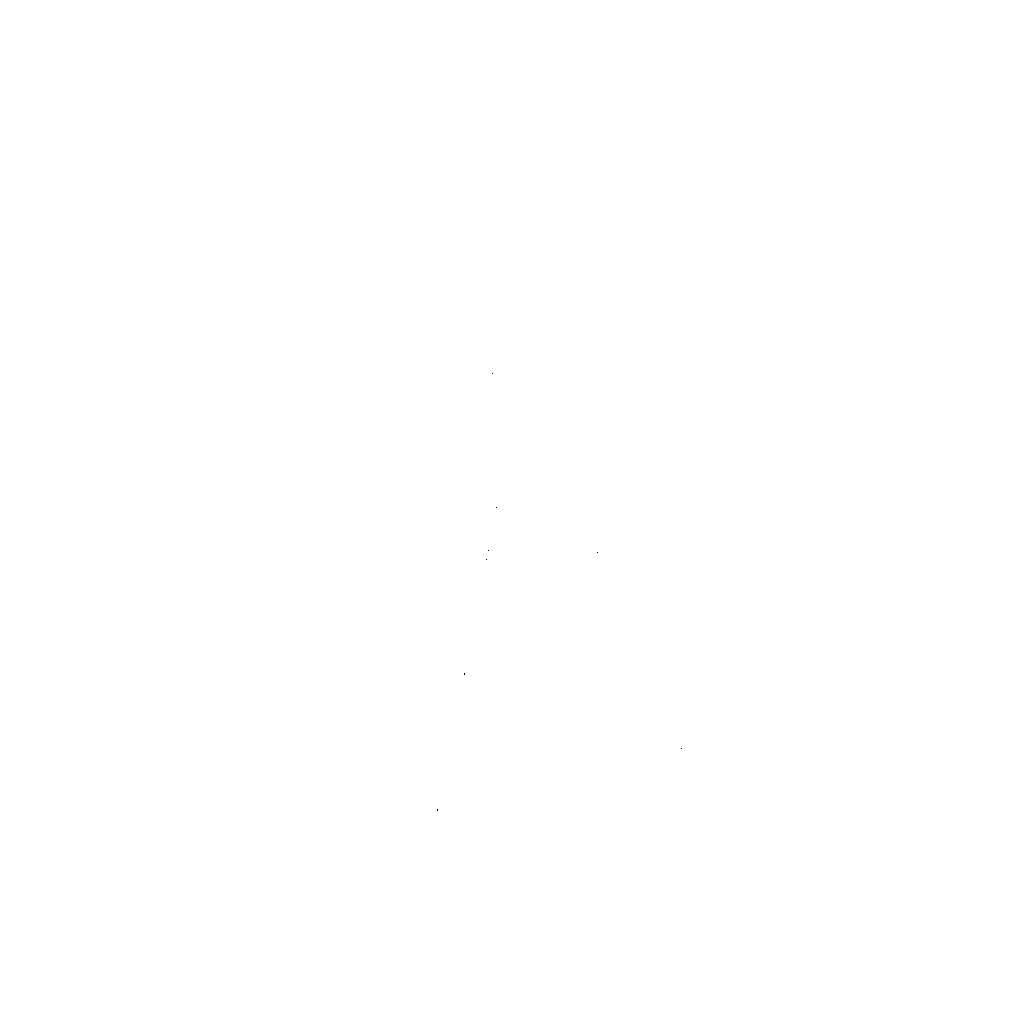

Threshold value: 50


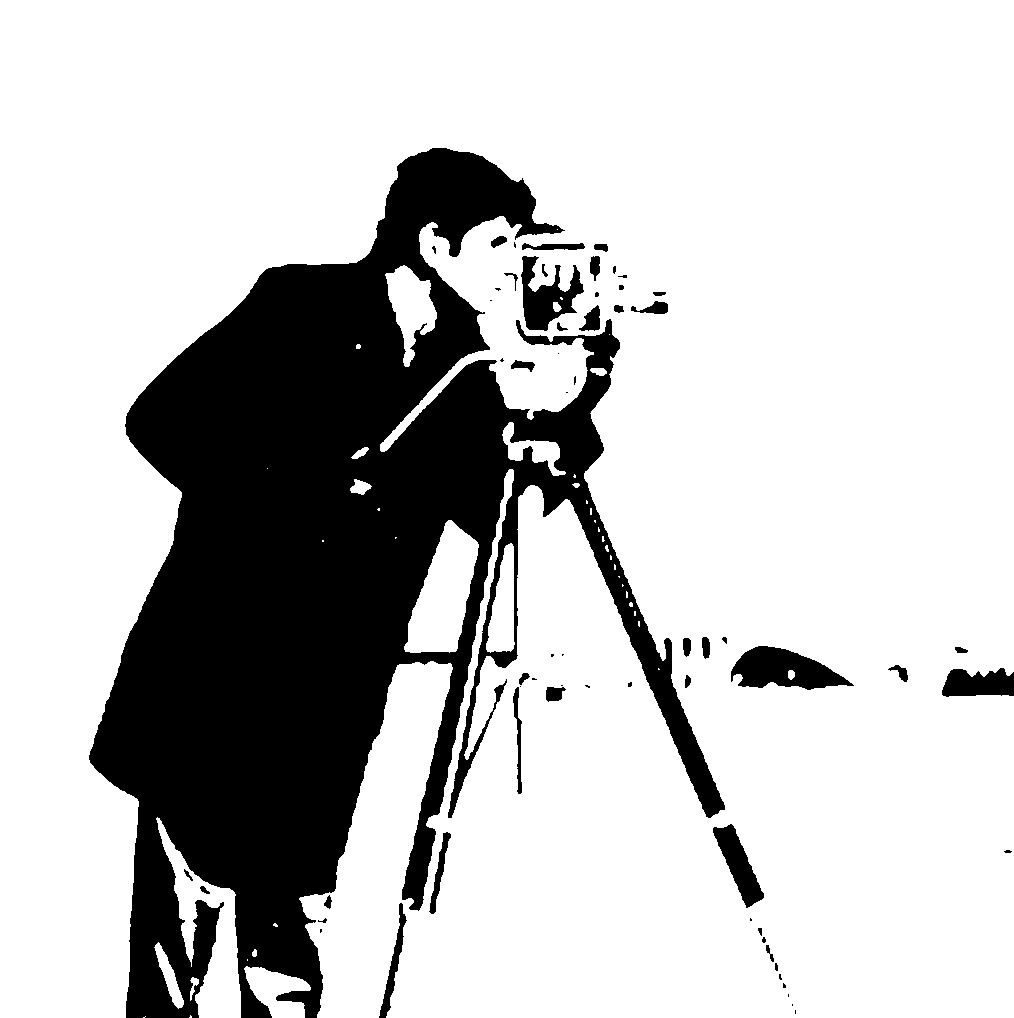

Threshold value: 100


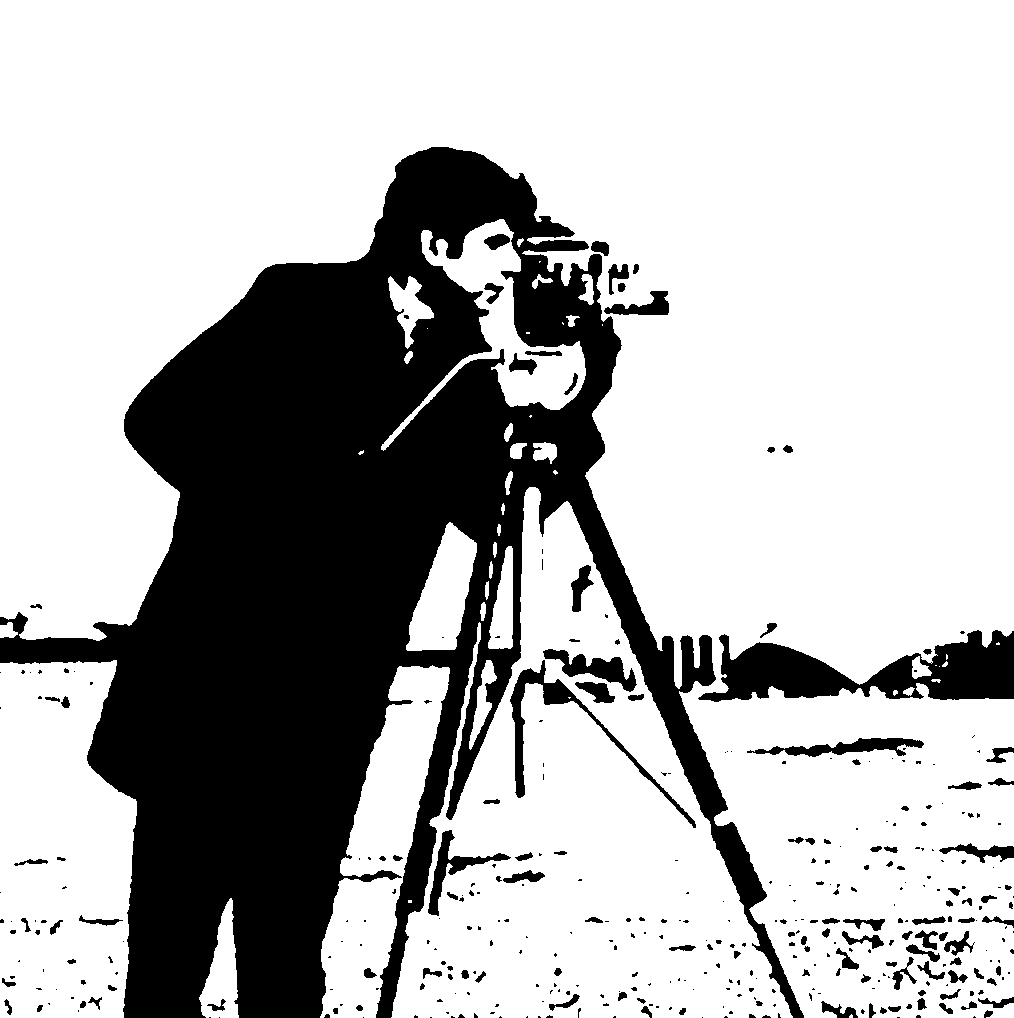

Threshold value: 150


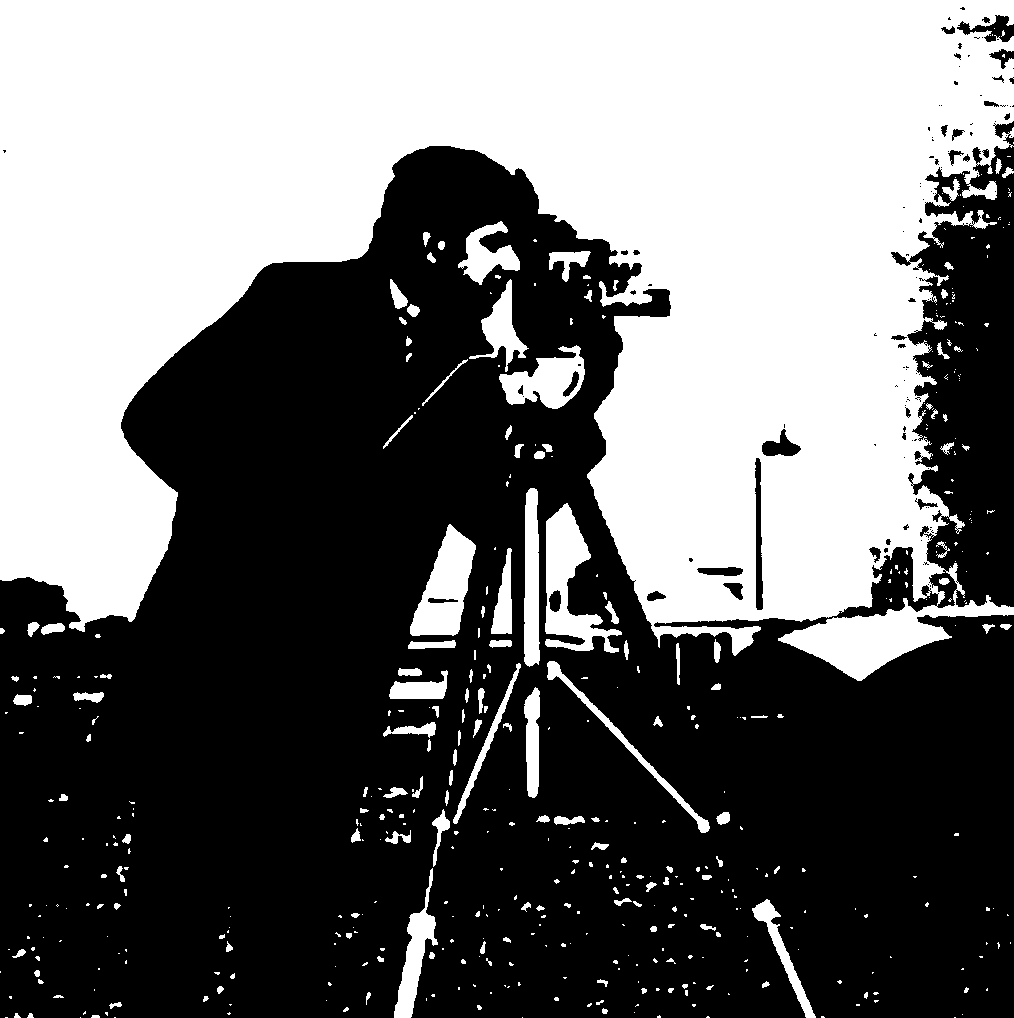

Threshold value: 200


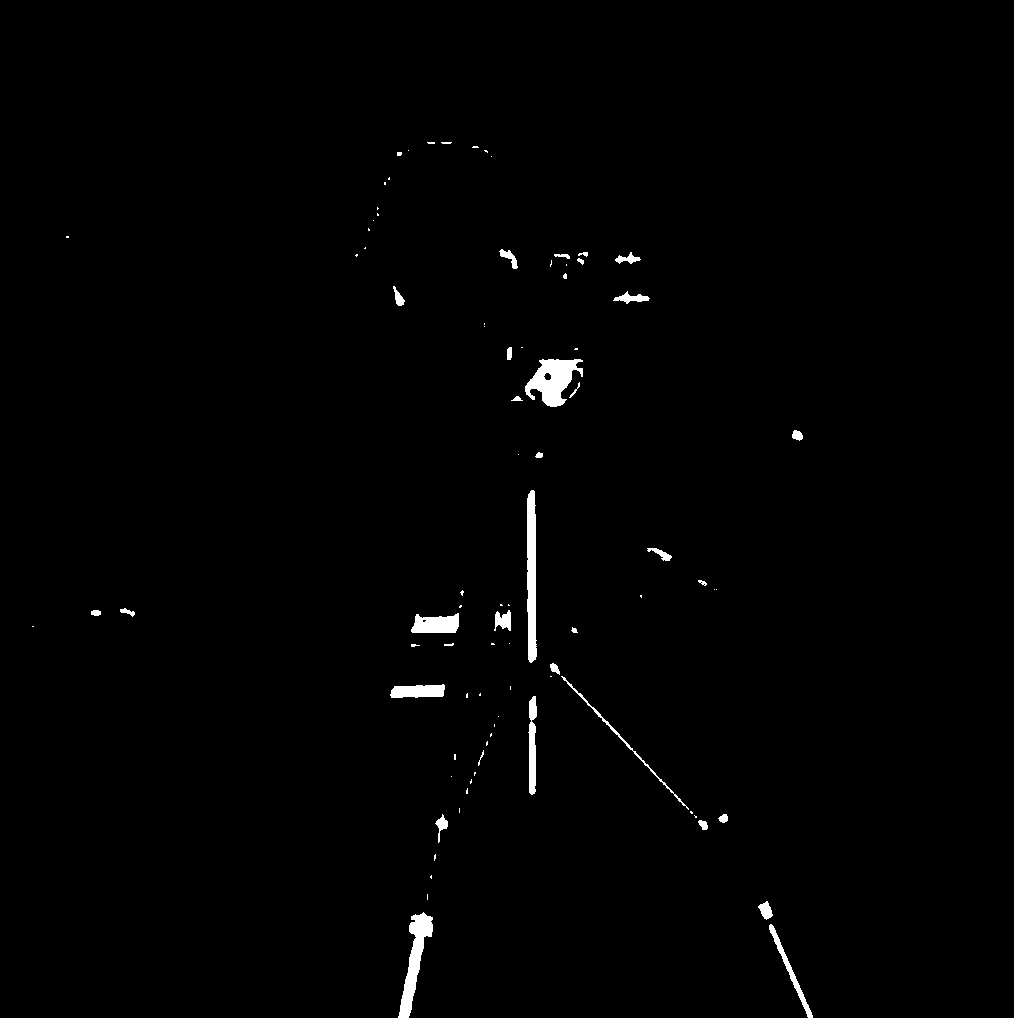

In [8]:
import cv2
from google.colab.patches import cv2_imshow

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


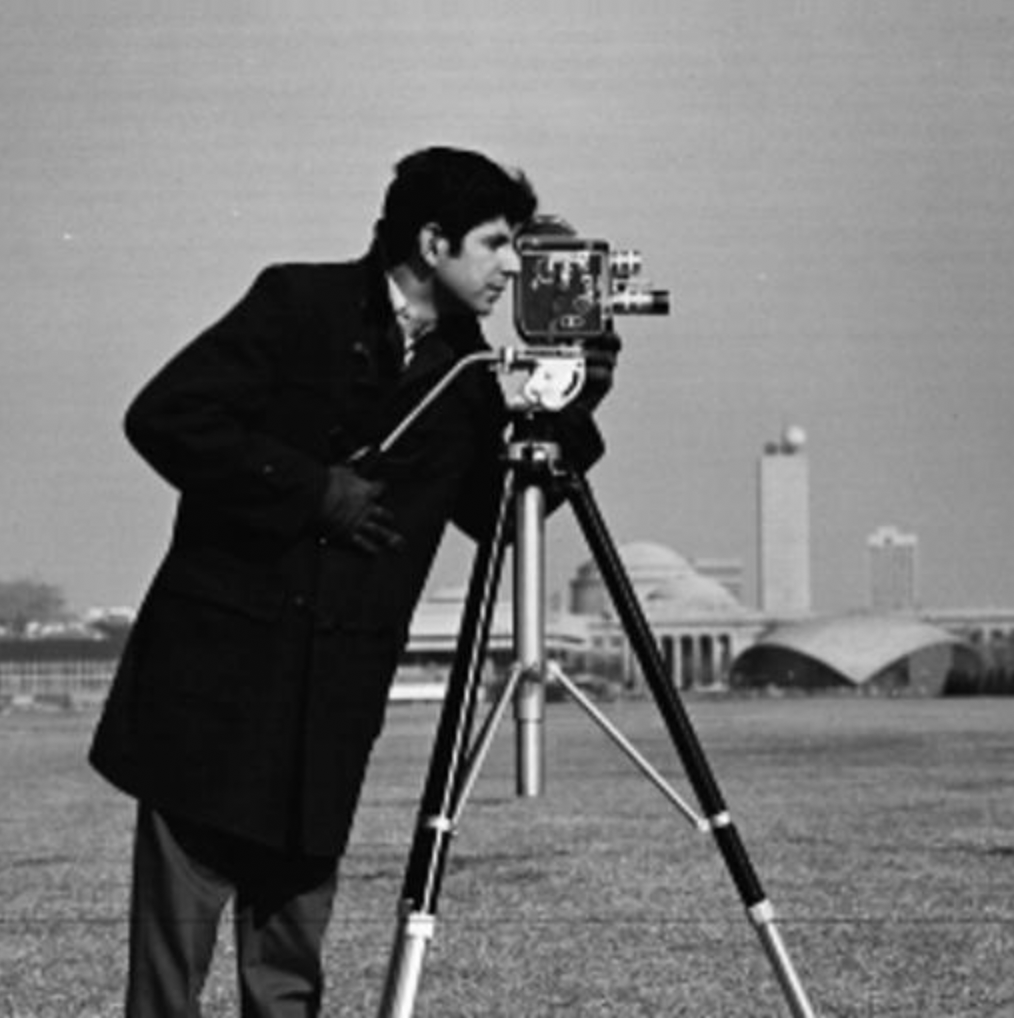

In [9]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

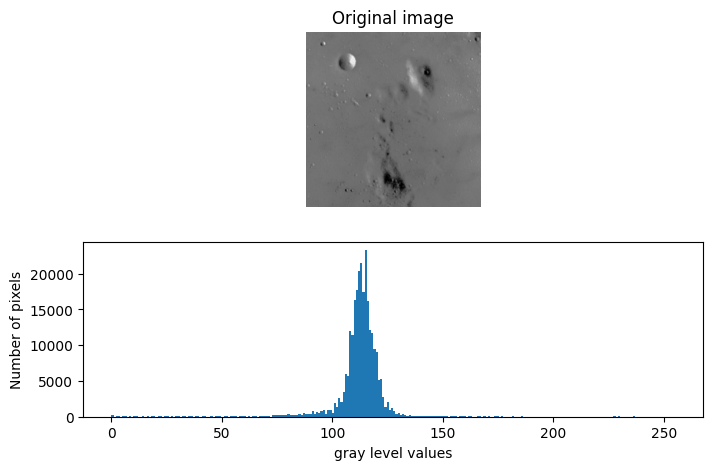

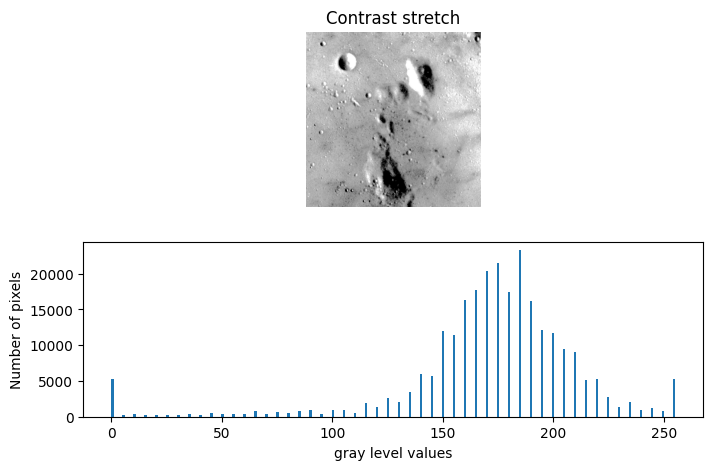

In [10]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


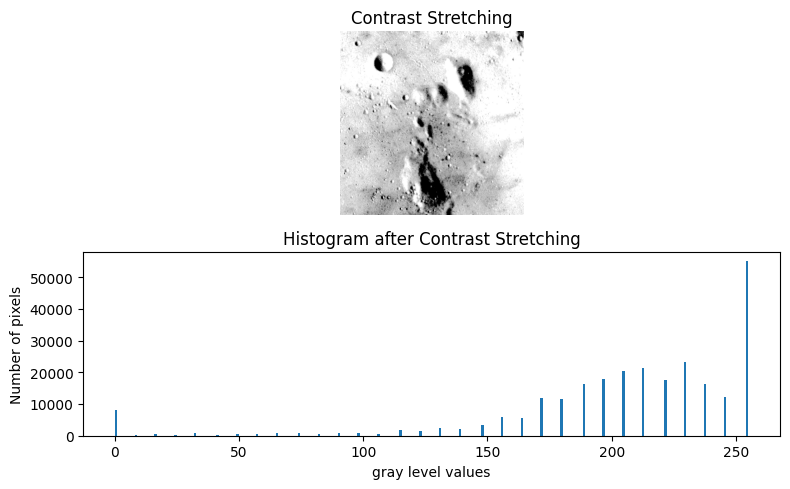

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure

img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

plt.figure(figsize=(8, 5))

plt.subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretching')

plt.subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram after Contrast Stretching')

plt.tight_layout()
plt.show()

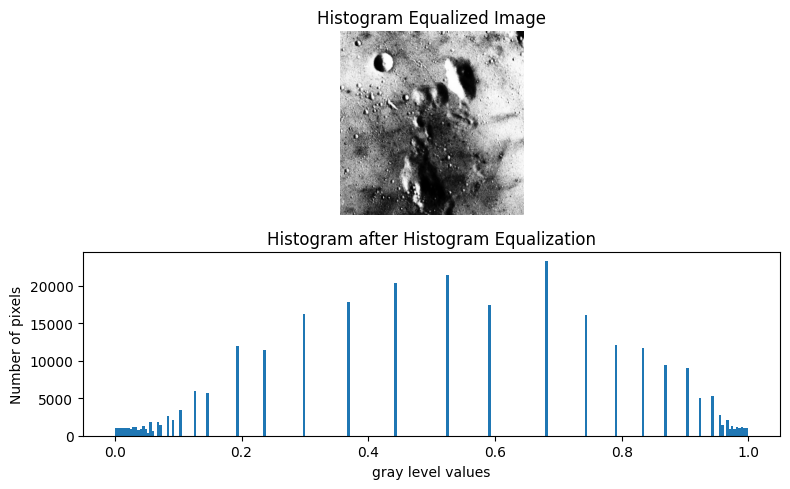

In [5]:
import matplotlib.pyplot as plt
from skimage import data, exposure

img = data.moon()

img_equalized = exposure.equalize_hist(img)

plt.figure(figsize=(8, 5))

plt.subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized Image')

plt.subplot(2, 1, 2)
plt.hist(img_equalized.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram after Histogram Equalization')

plt.tight_layout()
plt.show()

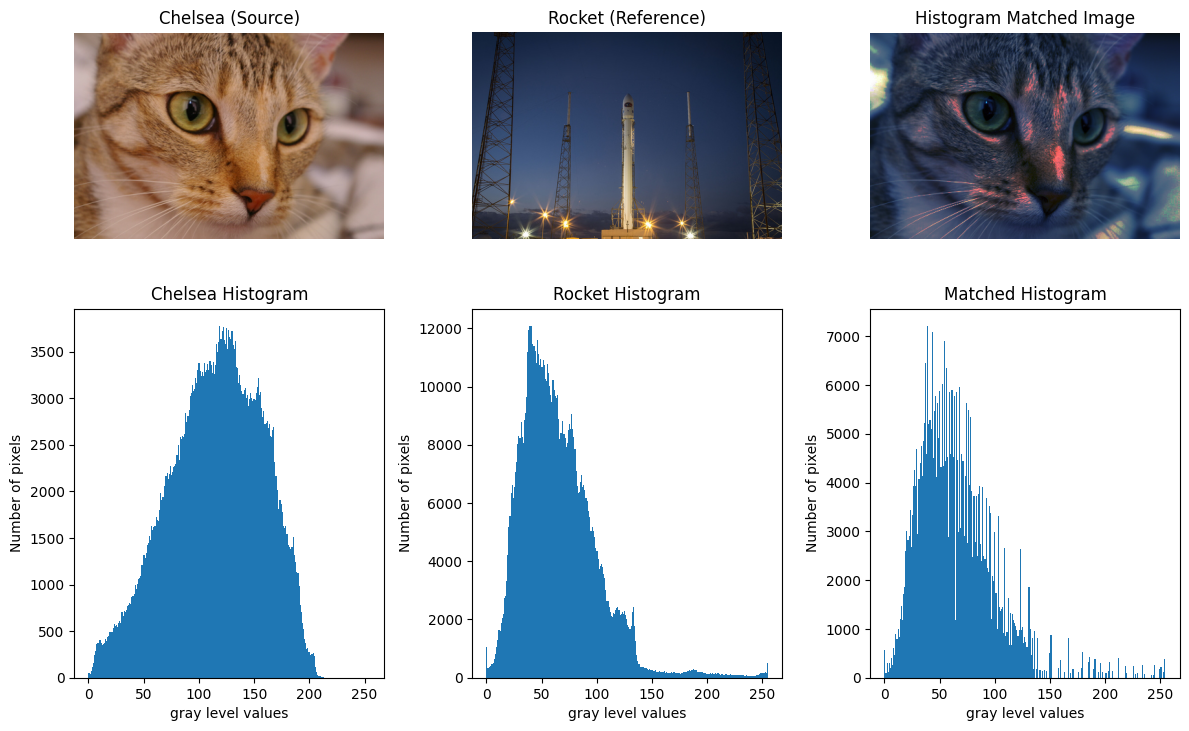

In [6]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.exposure import match_histograms

reference = data.rocket()
source = data.chelsea()

matched = match_histograms(source, reference, channel_axis=-1)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(source)
plt.axis('off')
plt.title('Chelsea (Source)')

plt.subplot(2, 3, 2)
plt.imshow(reference)
plt.axis('off')
plt.title('Rocket (Reference)')

plt.subplot(2, 3, 3)
plt.imshow(matched)
plt.axis('off')
plt.title('Histogram Matched Image')

plt.subplot(2, 3, 4)
plt.hist(source.ravel(), bins=256, range=(0, 255))
plt.title('Chelsea Histogram')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.subplot(2, 3, 5)
plt.hist(reference.ravel(), bins=256, range=(0, 255))
plt.title('Rocket Histogram')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.subplot(2, 3, 6)
plt.hist(matched.ravel(), bins=256, range=(0, 255))
plt.title('Matched Histogram')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()